1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [4]:
df = pd.read_csv('crop_yield.csv')
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


3. Basic Inspection

In [7]:
df.info()
print(df.isnull().sum())
print("Duplicate Rows : ", df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64
Duplicate Rows :  0


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


4. Data Cleaning

Yield Skewness : 12.785264685628691


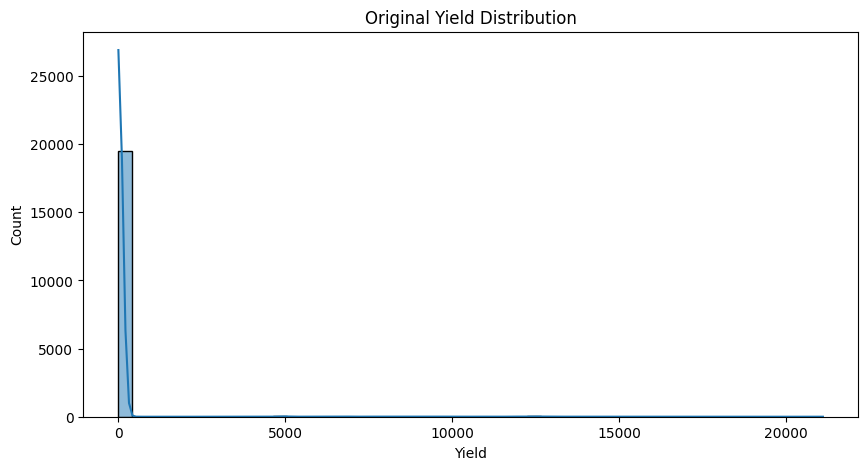

In [8]:
print("Yield Skewness :", df["Yield"].skew())
plt.figure(figsize=(10,5))
sns.histplot(df["Yield"], bins=50, kde=True)
plt.title("Original Yield Distribution")
plt.show()

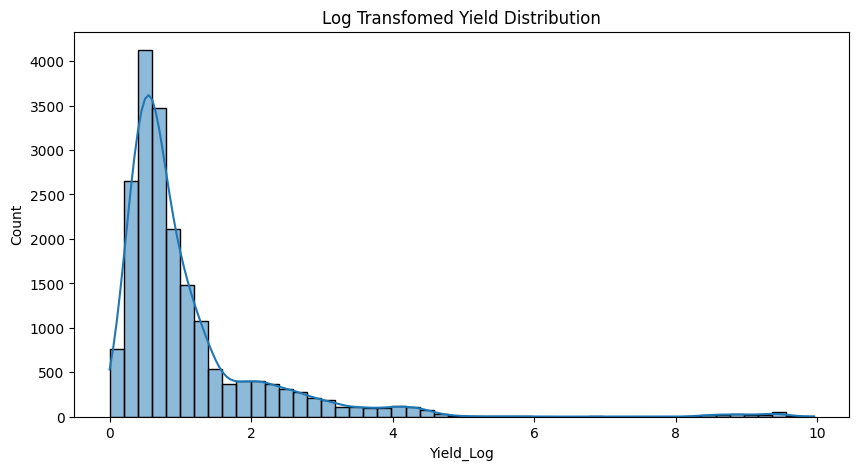

In [9]:
df["Yield_Log"] = np.log1p(df["Yield"])
plt.figure(figsize=(10,5))
sns.histplot(df["Yield_Log"], bins=50, kde=True)
plt.title("Log Transfomed Yield Distribution")
plt.show()

5. EDA (Exploratory Data Analysis)

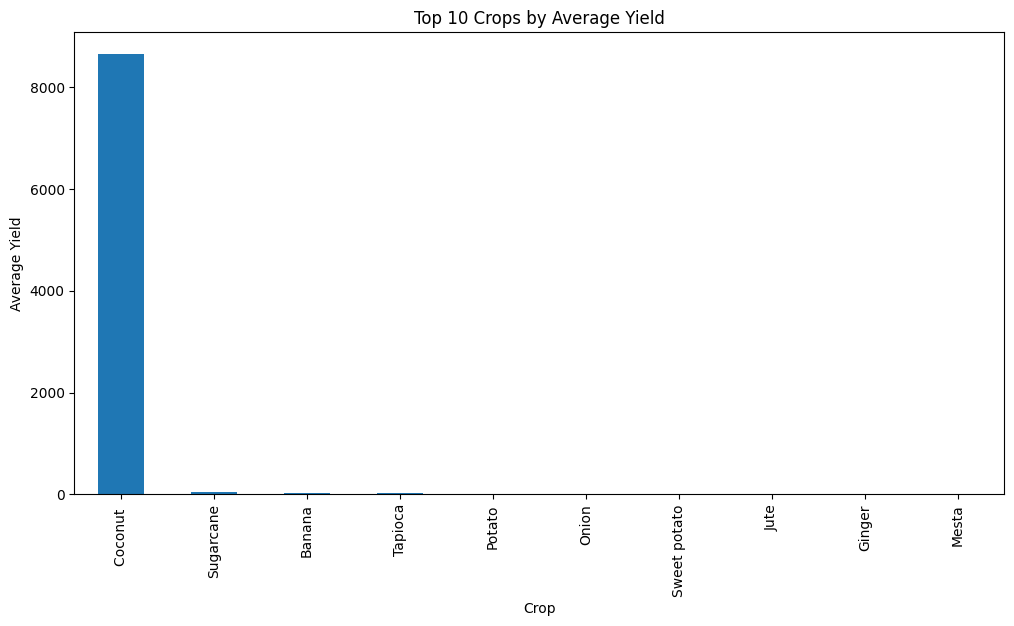

In [10]:
top_crop = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_crop.plot(kind="bar")
plt.title("Top 10 Crops by Average Yield")
plt.ylabel("Average Yield")
plt.show()

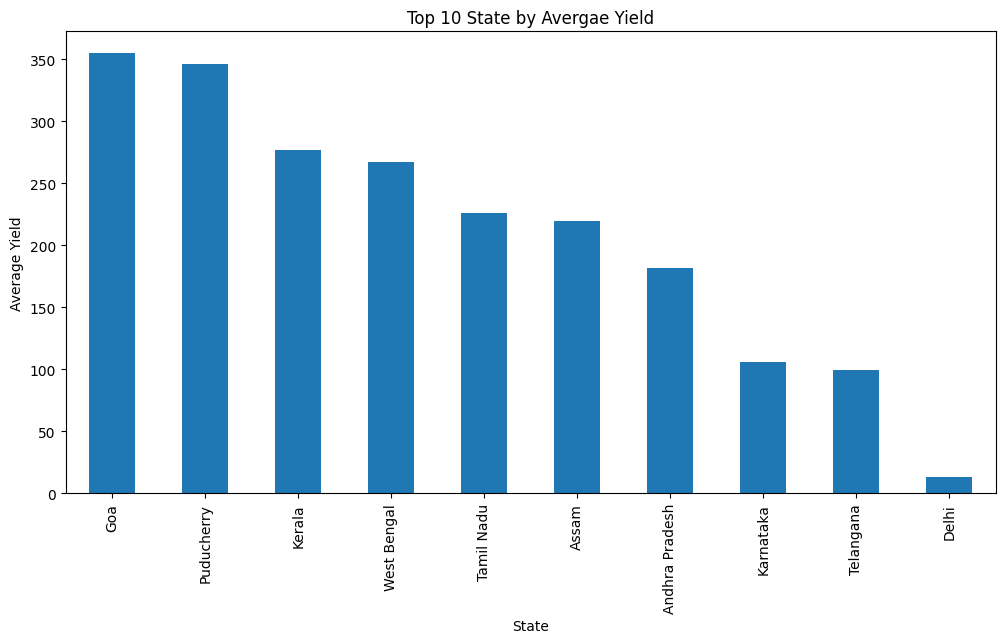

In [11]:
top_state = df.groupby("State")["Yield"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_state.plot(kind="bar")
plt.title("Top 10 State by Avergae Yield")
plt.ylabel("Average Yield")
plt.show()

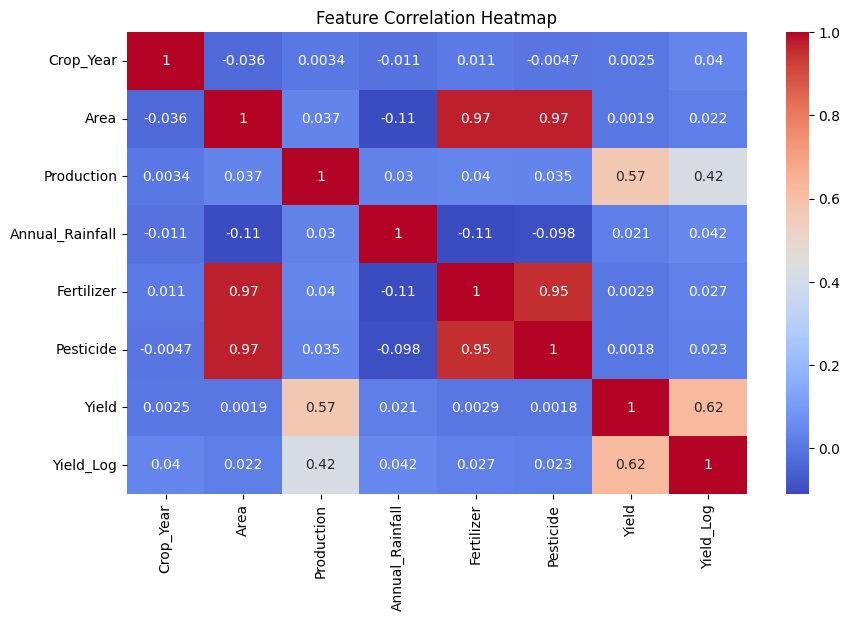

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

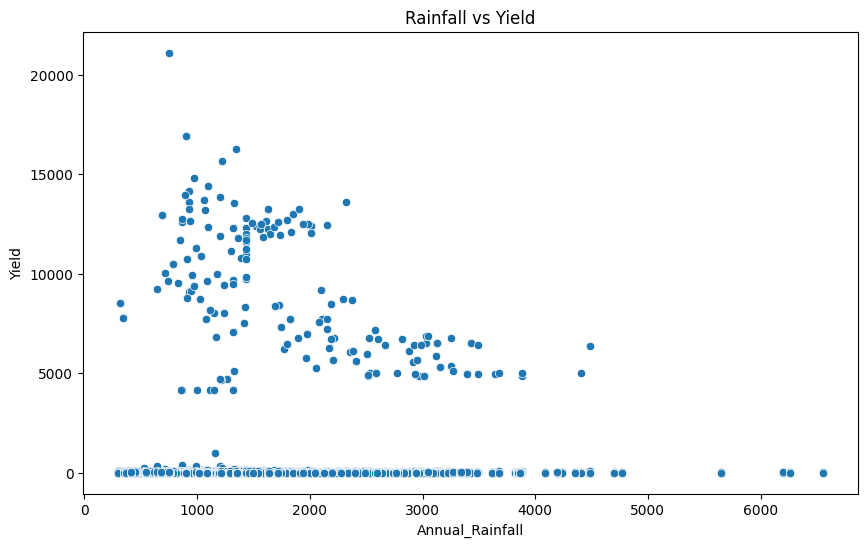

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Annual_Rainfall"], y=df["Yield"])
plt.title("Rainfall vs Yield")
plt.show()

6. Preprocessing

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data = df.copy()

le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

data["Crop"] = le_crop.fit_transform(data["Crop"])
data["Season"] = le_season.fit_transform(data["Season"])
data["State"] = le_state.fit_transform(data["State"])

X = data.drop(["Yield", "Yield_Log", "Production"], axis=1)

y = data["Yield_Log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape : ", X_train.shape)
print("Testing Shape : ", X_test.shape)

Training Shape :  (15751, 8)
Testing Shape :  (3938, 8)


7. Model Training


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

print("All models Trained Successfully.")

All models Trained Successfully.


8. Evaluation

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_model(model, name):
  pred = model.predict(X_test)

  r2 = r2_score(y_test, pred)
  rmse = np.sqrt(mean_squared_error(y_test, pred))
  mae = mean_absolute_error(y_test, pred)

  print(f"{name}")
  print("R2 Score : ", round(r2,4))
  print("RMSE     : ", round(rmse,4))
  print("MAE      : ", round(mae,4))
  print("-"*30)

evaluate_model(lr, "Linear Regression")
evaluate_model(rf, "Random Forest")
evaluate_model(xgb, "XGBoost")


Linear Regression
R2 Score :  0.1245
RMSE     :  1.0503
MAE      :  0.6546
------------------------------
Random Forest
R2 Score :  0.9587
RMSE     :  0.2283
MAE      :  0.1245
------------------------------
XGBoost
R2 Score :  0.9292
RMSE     :  0.2988
MAE      :  0.187
------------------------------


9. Save Best Model

In [ ]:
import pickle

with open("best_crop_model.pkl", "wb") as f:
  pickle.dump(rf, f)

print("Model Saved Successfully")

Model Saved Successfully


10. Prediction System

In [ ]:
sample = X_test.iloc[[0]]

pred_log = rf.predict(sample)[0]

pred_yield = np.expm1(pred_log)

print("Predicted Yield : ", round(pred_yield,2), "units per hectare")

Predicted Yield :  2.87 units per hectare


11. Feature Importance Graph

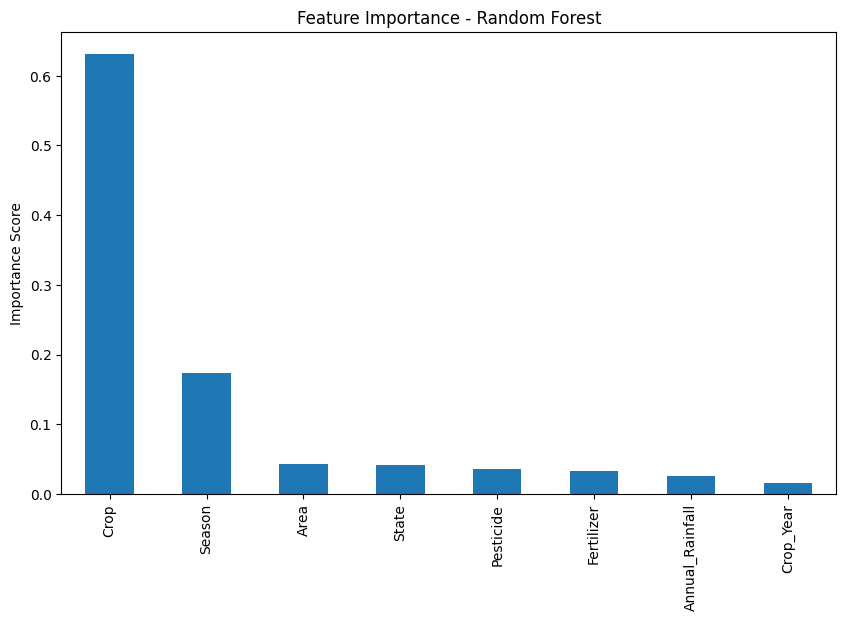

In [ ]:
importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
data.to_csv("processed_crop_yield.csv", index=False)
print("Processed dataset saved.")

Processed dataset saved.


# 12. Charts for the output

# (i)

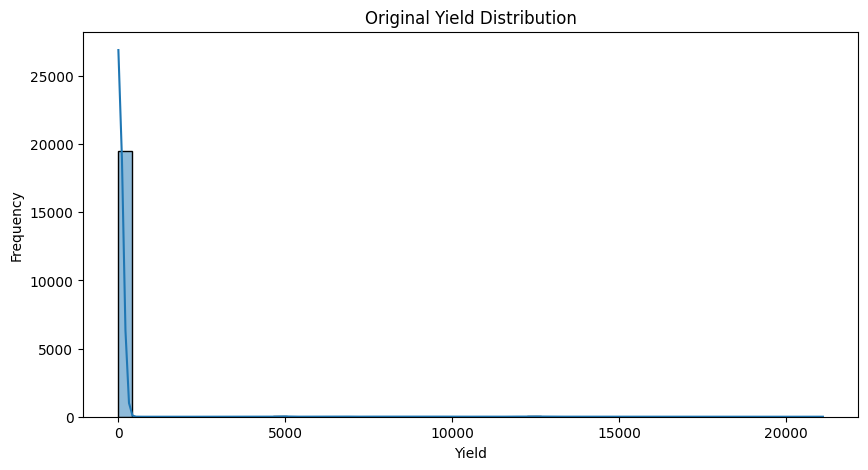

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["Yield"], bins=50, kde=True)
plt.title("Original Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.savefig("yield_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# (ii)

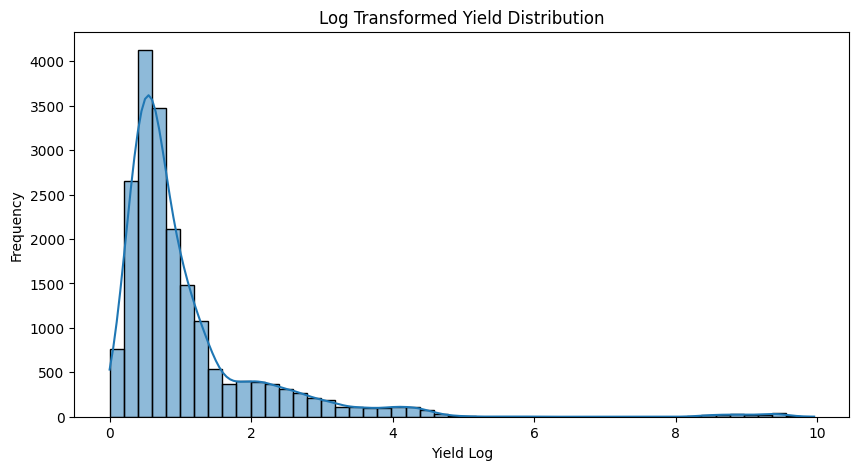

In [ ]:
df["Yield_Log"] = np.log1p(df["Yield"])

plt.figure(figsize=(10,5))
sns.histplot(df["Yield_Log"], bins=50, kde=True)
plt.title("Log Transformed Yield Distribution")
plt.xlabel("Yield Log")
plt.ylabel("Frequency")

plt.savefig("log_yield_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#(iii)

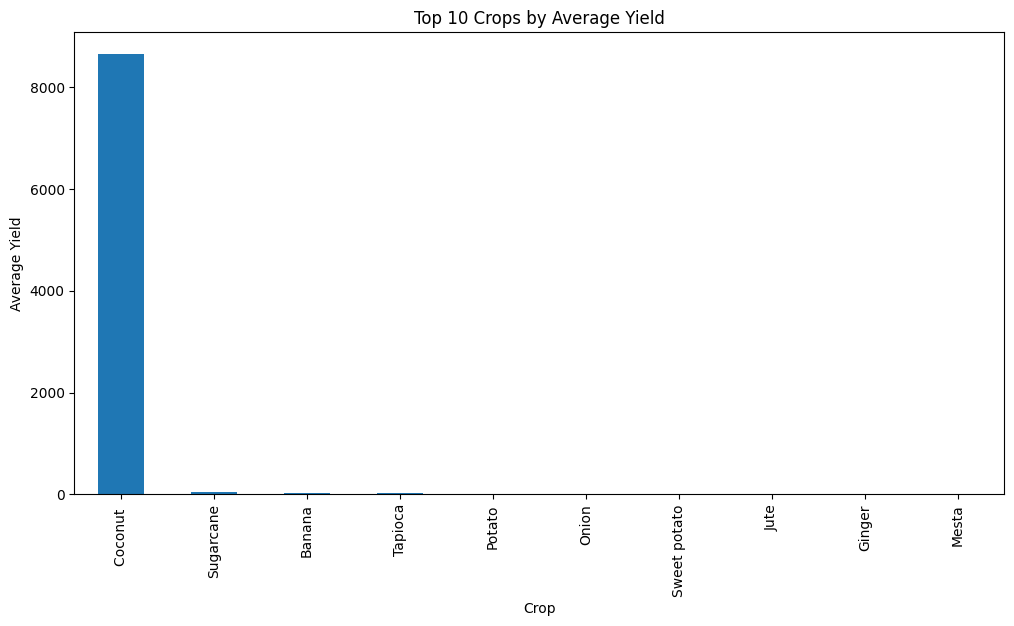

In [ ]:
top_crop = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_crop.plot(kind="bar")
plt.title("Top 10 Crops by Average Yield")
plt.ylabel("Average Yield")

plt.savefig("top_10_crops.png", dpi=300, bbox_inches="tight")
plt.show()

# (iv)

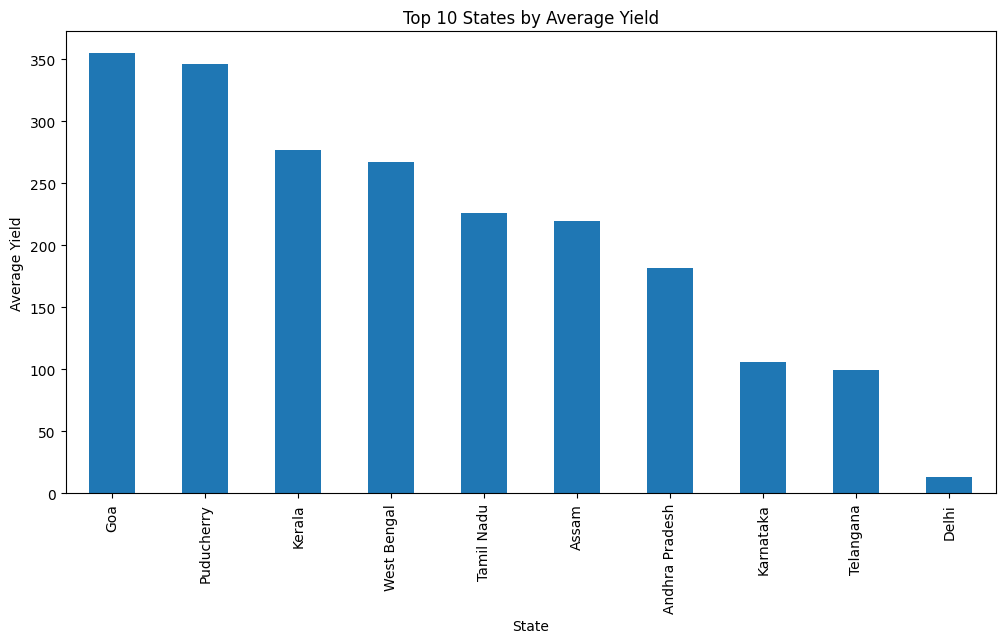

In [ ]:
top_state = df.groupby("State")["Yield"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_state.plot(kind="bar")
plt.title("Top 10 States by Average Yield")
plt.ylabel("Average Yield")

plt.savefig("top_10_states.png", dpi=300, bbox_inches="tight")
plt.show()

# (v)

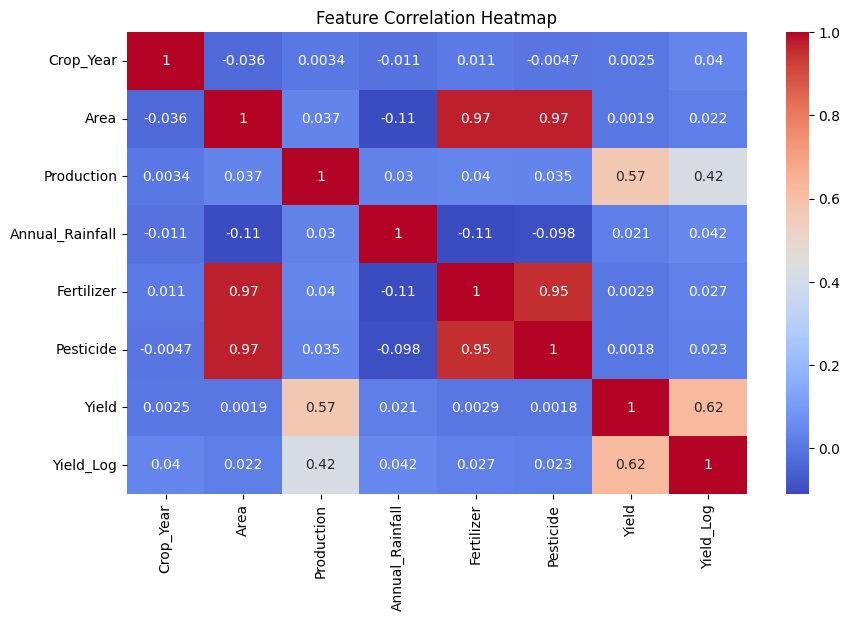

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# (vi)

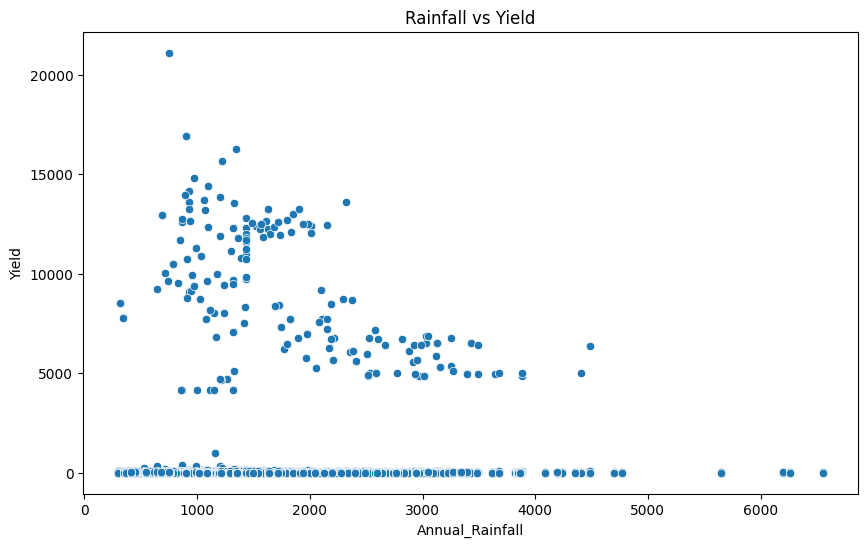

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Annual_Rainfall"], y=df["Yield"])
plt.title("Rainfall vs Yield")

plt.savefig("rainfall_vs_yield.png", dpi=300, bbox_inches="tight")
plt.show()

# (vii)

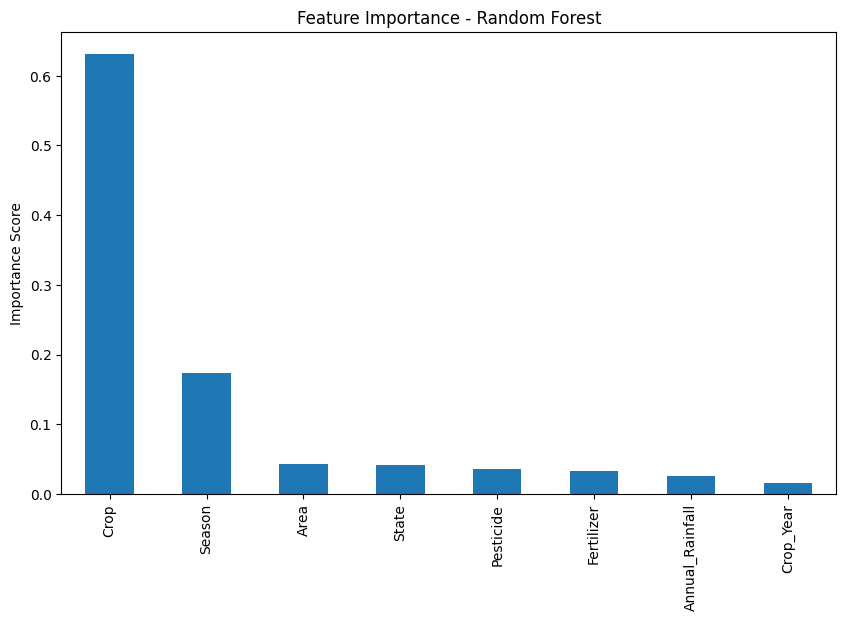

In [17]:
importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()